In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/titanic_cleaned.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [5]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['TravelAlone'] = np.where(
    df['FamilySize'] == 1,
    'Alone',
    'With Family'
)

In [6]:
df[['SibSp', 'Parch', 'FamilySize', 'TravelAlone']].head()

,SibSp,Parch,FamilySize,TravelAlone
0,1,0,2,With Family
1,1,0,2,With Family
2,0,0,1,Alone
3,1,0,2,With Family
4,0,0,1,Alone


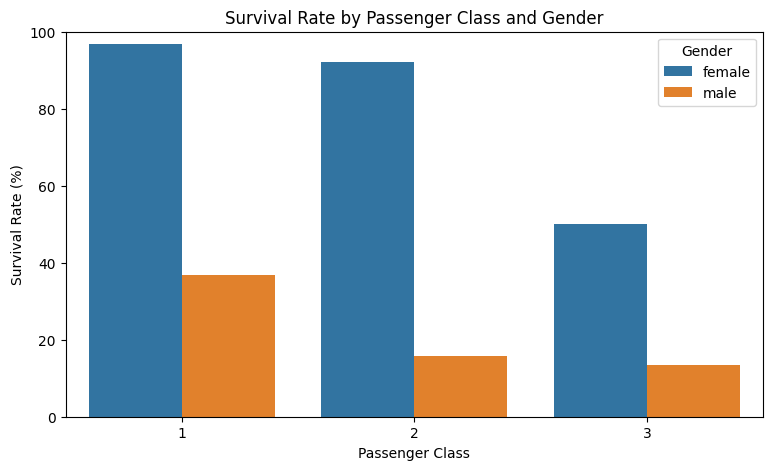

In [8]:
survival_class_gender = (
    df.groupby(['Pclass', 'Sex'])['Survived']
      .mean()
      .reset_index()
)

survival_class_gender['SurvivalRate'] = (
    survival_class_gender['Survived'] * 100
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=survival_class_gender,
    x='Pclass',
    y='SurvivalRate',
    hue='Sex'
)

plt.title('Survival Rate by Passenger Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.legend(title='Gender')
plt.savefig('survival_class_gender.png', dpi=300, bbox_inches='tight')
plt.show()

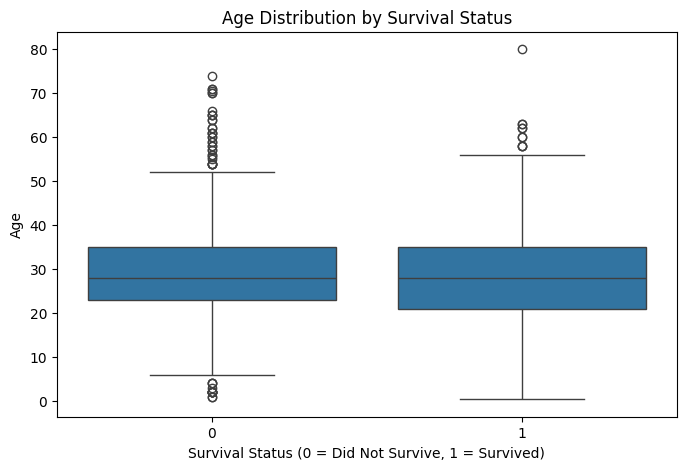

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Survived',
    y='Age'
)

plt.title('Age Distribution by Survival Status')
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Age')

plt.savefig('age_survival_boxplot.png', dpi=300, bbox_inches='tight')

plt.show()

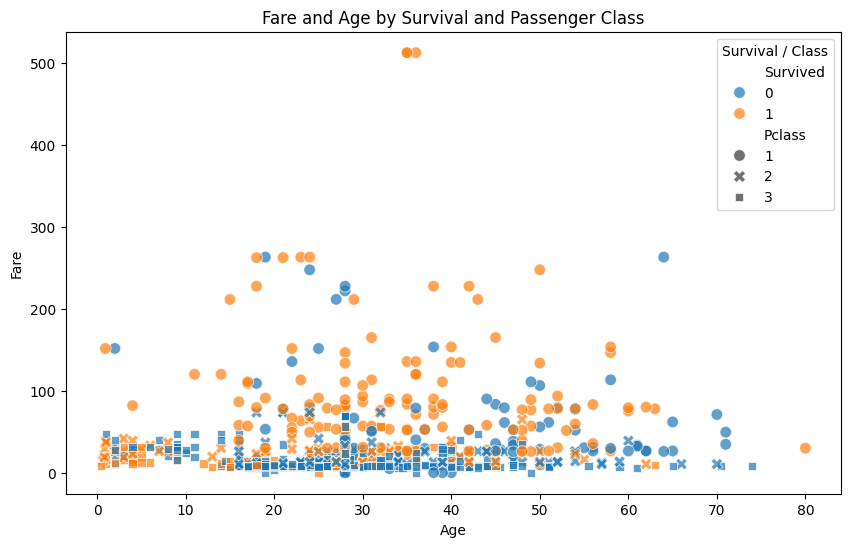

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Fare',
    hue='Survived',
    style='Pclass',
    s=70,
    alpha=0.7
)

plt.title('Fare and Age by Survival and Passenger Class')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(title='Survival / Class')
plt.savefig('fare_age_survival_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
def family_category(size):
    if size == 1:
        return 'Alone'
    elif size <= 4:
        return 'Small Family'
    else:
        return 'Large Family'

df['FamilyCategory'] = df['FamilySize'].apply(family_category)

In [12]:
df[['FamilySize', 'FamilyCategory', 'Survived']].head()

,FamilySize,FamilyCategory,Survived
0,2,Small Family,0
1,2,Small Family,1
2,1,Alone,1
3,2,Small Family,1
4,1,Alone,0


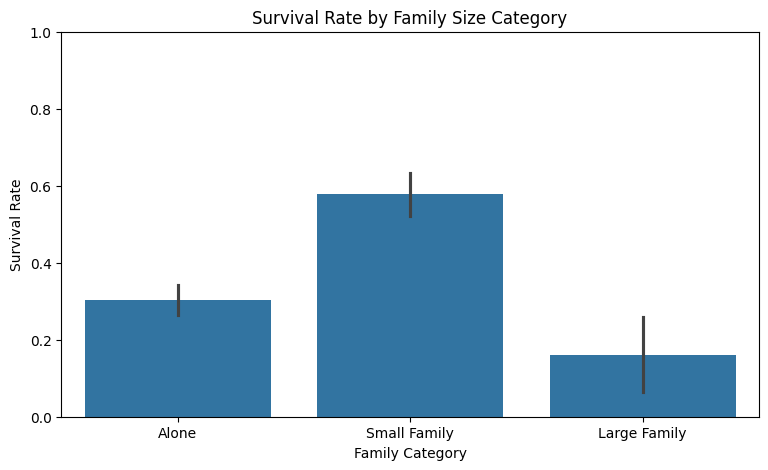

In [13]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x='FamilyCategory',
    y='Survived',
    order=['Alone', 'Small Family', 'Large Family']
)

plt.title('Survival Rate by Family Size Category')
plt.xlabel('Family Category')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)

plt.show()

/tmp/ipykernel_8991/100483218.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{x*100:.0f}%' for x in ax.get_yticks()])


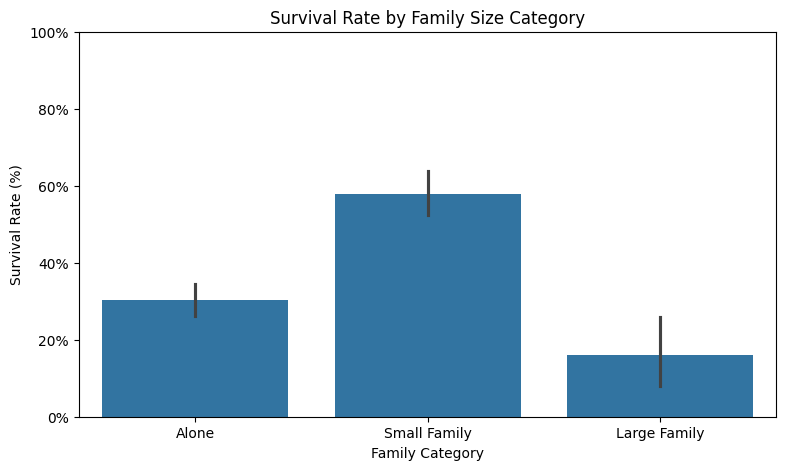

In [14]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=df,
    x='FamilyCategory',
    y='Survived',
    order=['Alone', 'Small Family', 'Large Family']
)

plt.title('Survival Rate by Family Size Category')
plt.xlabel('Family Category')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 1)

ax.set_yticklabels([f'{x*100:.0f}%' for x in ax.get_yticks()])

plt.savefig(
    'family_size_survival.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

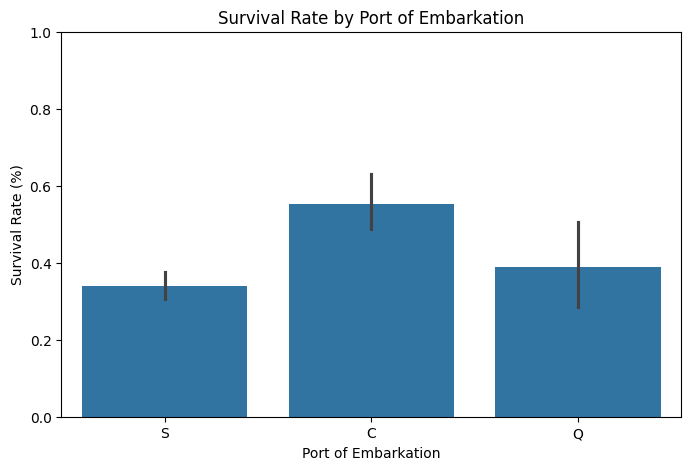

In [15]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x='Embarked',
    y='Survived'
)

plt.title('Survival Rate by Port of Embarkation')
plt.xlabel('Port of Embarkation')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 1)

plt.savefig(
    'survival_by_embarkation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()